# Segunda Práctica: Determinación de tipos de estrellas

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente.
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López

## 1. Codificación ordinal de variables categóricas


A continuación vamos a codificar las variables categóricas (color, clase espectral), teniendo en cuenta que el color está asociado a la cantidad de energía, y algo parecido con la clase espectral.

Lo primero que haremos es importar todas las librerias que vamos a necesitar en la práctica y establecer la semilla:

In [2]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib import style
style.use('ggplot')

# Preprocesado
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram

# Reproducibilidad
SEED = 100522236
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


También cargaremos los datos y los exploraremos:

In [3]:
# Cargamos el dataset
df = pd.read_csv('stars_data.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


In [5]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [6]:
# Valores únicos en variables categóricas
print('Colores únicos:', sorted(df['Color'].unique()))
print('Clases espectrales únicas:', sorted(df['Spectral_Class'].unique()))

Colores únicos: ['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']
Clases espectrales únicas: ['A', 'B', 'F', 'G', 'K', 'M', 'O']


Ahora codificaremos las variables categóricas, que son la clase Espectral y la clase Color, ya que están asociados a la temperatura y energía de la estrella y son strings. Esto no lo podemos hacer con One-Hot Encoding porque perderíamos la información de orden y herarquía que existe en la naturaleza física de las estrellas, ya que no son categorías independientes, sino una progesión térmica.

-La clase espectral la codificaremos con una secuencia (de más caliente a más fría), conocida como la secuencia de Harvard: O -> B -> A -> F -> G -> K -> M

Esta secuencia tiene sentido ya que las estrellas tipo O son las más masivas y calientes, mientras que las tipo M son las más frías y pequeñas. Les asignaaremos valores del 0 al 6 para que el algoritmo entienda esta relación de magnitud.

-La clase color la codificaremos de azul a rojo, ya que el azul es como más energético y el rojo menos energético, siguiendo el espectro electromagnético visible.


In [7]:
# Codificación ordinal de Clase Espectral (de mayor a menor temperatura)
spectral_order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df['Spectral_Class_enc'] = df['Spectral_Class'].map(spectral_order)

# Codificación ordinal de Color 
# Primero normalizamos el texto (strip + lower) para evitar problemas de formato
df['Color_clean'] = df['Color'].str.strip().str.lower()
print('Colores normalizados:', sorted(df['Color_clean'].unique()))

# Orden de colores de mayor temperatura (azul) a menor (rojo)
color_order = {
    'blue':              0,
    'blue-white':        1,
    'blue white':        1,
    'pale yellow orange':2,
    'white':             3,
    'whitish':           3,
    'yellowish white':   4,
    'yellow-white':      4,
    'white-yellow':      4,
    'yellow white':      4,
    'yellowish':         5,
    'orange':            6,
    'orange-red':        7,
    'red':               8,
}

df['Color_enc'] = df['Color_clean'].map(color_order)

# Comprobamos que no haya NaN (colores no mapeados)
unmapped = df[df['Color_enc'].isna()]['Color_clean'].unique()
if len(unmapped) > 0:
    print('⚠️  Colores sin mapear:', unmapped)
    # Asignar la mediana como valor por defecto para no perder filas
    df['Color_enc'].fillna(df['Color_enc'].median(), inplace=True)
else:
    print('Todos los colores han sido mapeados correctamente.')

df[['Color', 'Color_enc', 'Spectral_Class', 'Spectral_Class_enc']].head(10)

Colores normalizados: ['blue', 'blue white', 'blue-white', 'orange', 'orange-red', 'pale yellow orange', 'red', 'white', 'white-yellow', 'whitish', 'yellow-white', 'yellowish', 'yellowish white']
Todos los colores han sido mapeados correctamente.


,Color,Color_enc,Spectral_Class,Spectral_Class_enc
0,Red,8,M,6
1,Red,8,M,6
2,Red,8,M,6
3,Red,8,M,6
4,Red,8,M,6
5,Red,8,M,6
6,Red,8,M,6
7,Red,8,M,6
8,Red,8,M,6
9,Red,8,M,6


In [8]:
# Dataset final con variables numéricas para el modelado
features = ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']
X = df[features].copy()
print('Features seleccionadas:', features)
X.describe()

Features seleccionadas: ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']


,Temperature,L,R,A_M,Color_enc,Spectral_Class_enc
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,4.404167,3.479167
std,9552.425037,179432.244940,517.155763,10.532512,3.574547,2.531720
min,1939.000000,0.000080,0.008400,-11.920000,0.000000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,4.000000,3.000000
75%,15055.500000,198050.000000,42.750000,13.697500,8.000000,6.000000
max,40000.000000,849420.000000,1948.500000,20.060000,8.000000,6.000000


## 2. Reducción dimensional con PCA (2 componentes)

Antes del clustering se aplica PCA para facilitar la visualización y mejorar la tarea de clustering (agrupamiento).

Utilizamos el escalador éstandar (StandardScaler) ya que las características de los datos poseen escalas y unidades de mediada muy diferentes, por lo que de esta forma aseguramos que cada atributo contribuya de manera equitativa a la construcción de los componentes principales, evitando que las variables con rángos numéricos más altos dominen el análisis por si solas.

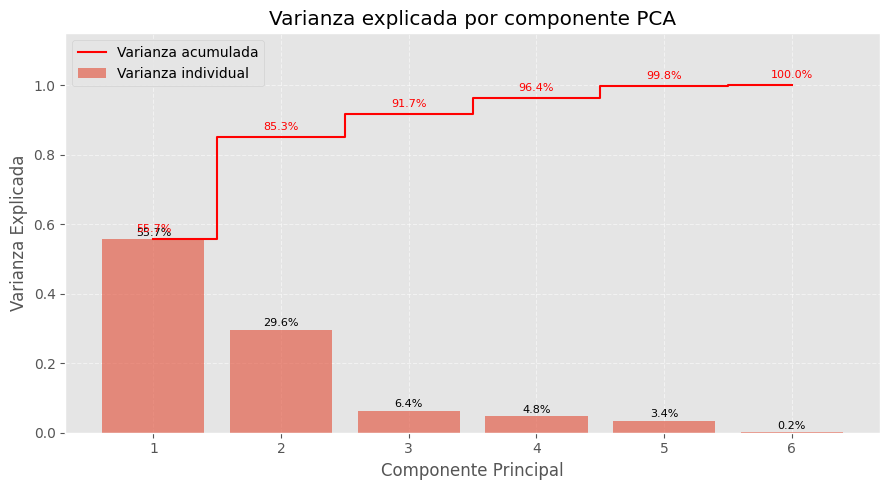

In [9]:
# Varianza explicada con todos los componentes
pipeline_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(random_state=SEED))
])
pipeline_full.fit(X)
pca_full = pipeline_full.named_steps['pca']

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Varianza individual')
ax.step(range(1, len(cumulative_var)+1), cumulative_var, where='mid',
        color='red', label='Varianza acumulada')

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    ax.text(i+1, ev+0.01, f'{ev:.1%}', ha='center', fontsize=8)
    ax.text(i+1, cv+0.02, f'{cv:.1%}', ha='center', fontsize=8, color='red')

ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada')
ax.set_title('Varianza explicada por componente PCA')
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Al analizar el gráfico, vemos que la primera componente captura aproximadamente el 55,7% de la información, mientras que la segunda añade un 29,6%. Estas dos dimensiones logran retener el 85,3% de la varianza total, lo que justicia el uso de solo dos componentes para las tareas de clustering posteriores, ya que simplifica la visualización y el cálculo, sin sacrificar una cantidad significativa de información.

Varianza explicada PC1: 55.69%
Varianza explicada PC2: 29.60%
Varianza total explicada: 85.29%


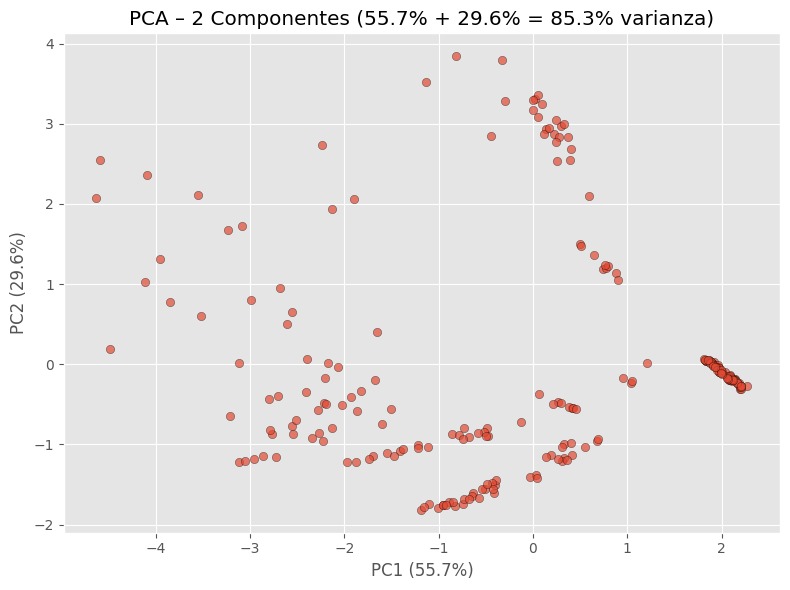

In [10]:
#  PCA con 2 componentes (pipeline final para el clustering) 
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=2, random_state=SEED))
])

X_pca = pipeline_pca.fit_transform(X)
pca2  = pipeline_pca.named_steps['pca']

var1 = pca2.explained_variance_ratio_[0]
var2 = pca2.explained_variance_ratio_[1]

print(f'Varianza explicada PC1: {var1:.2%}')
print(f'Varianza explicada PC2: {var2:.2%}')
print(f'Varianza total explicada: {var1+var2:.2%}')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k', linewidths=0.3)
ax.set_title(f'PCA – 2 Componentes ({var1:.1%} + {var2:.1%} = {var1+var2:.1%} varianza)')
ax.set_xlabel(f'PC1 ({var1:.1%})')
ax.set_ylabel(f'PC2 ({var2:.1%})')
plt.tight_layout()
plt.show()

Como vemos en este segundo gráfico, podemos distinguir grupos compactos y puntos más disperosos. Estos dos grupos nos servirán en los algoritmos de K-Means, Clustering Jerárquico y DBSCAN.

## 3. K-Means, Hierarchical Clustering/Dendrogramas y DBSCAN

A continuación aplicaremos los tres algoritmos de clustering que nos han explicado en clase y compararemos y discutiremos los resultados que se obtienen de ellos.

### 3.1. K-Means

Este método busca agrupar las estrellas minimizando la varianza intra-cluster (inercia). Para encontrar el mejor número de grupos (K) haremos un barrido de hiper-parámetros evaluando la métrica del Método del Codo y el Coeficiente de Silhouette. Este último es especialmente útil ya que mide qué tan similar es un objeto a su propio cluster en comparación a con otros clusters.

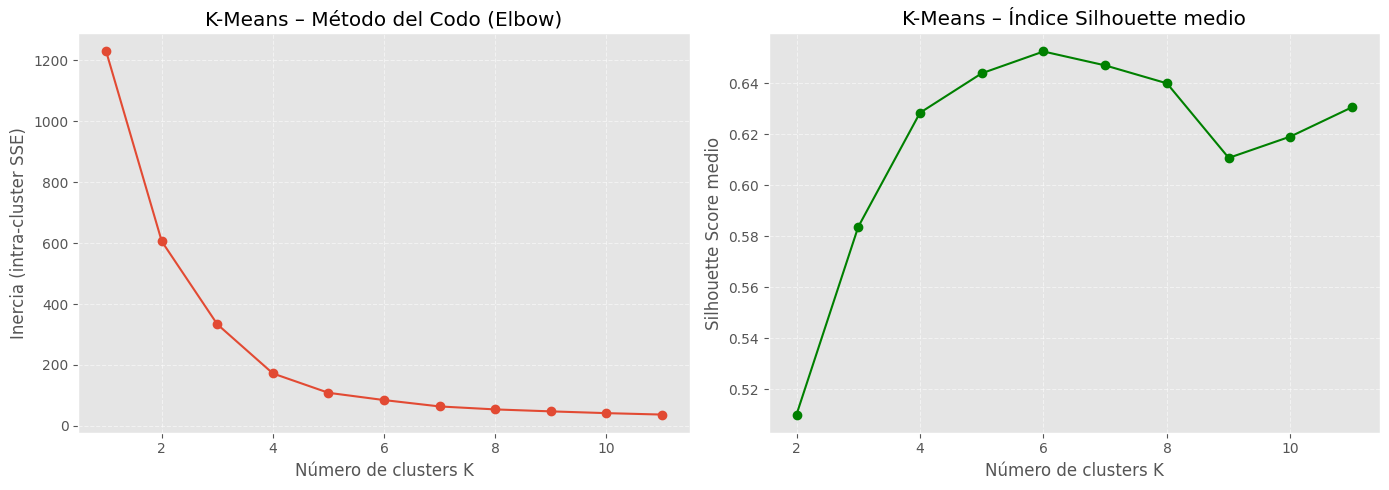

K óptimo según Silhouette: 6  (score=0.6525)


In [ ]:
# Método del Codo (Elbow) 
range_k     = range(1, 12)
inertias    = []
silhouettes = []

for k in range_k:
    km = KMeans(n_clusters=k, n_init=25, random_state=SEED)
    labels_k = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes.append(silhouette_score(X_pca, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method (método del codo)
axes[0].plot(list(range_k), inertias, marker='o')
axes[0].set_title('K-Means – Método del Codo (Elbow)')
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Inercia (intra-cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Coeficiente de Silhouette
axes[1].plot(list(range(2, 12)), silhouettes, marker='o', color='green')
axes[1].set_title('K-Means – Índice Silhouette medio')
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Silhouette Score medio')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

best_k_sil = list(range(2, 12))[np.argmax(silhouettes)]
print(f'K óptimo según Silhouette: {best_k_sil}  (score={max(silhouettes):.4f})')

Tras analizar los gráficos, observamos lo siguiente:

- En el gráfico del codo se ve un descenso pronunciado de la inercia hasta K=3 o K=4, y despues la reducción de la inercia se suaviza.

- En el gráfico del índice de Silhouuette vemos que hay un pico máximo global de 0,6525 para K=6

Como el valor de Silhouette cercano a 1 indica una estructura de cluster muy sólida y puntos bien asignados, seleccionaremos K=6 como el número de clusters, que coincide con la clasificación taxonómica estándar de la astronomia presentada en el enunciado.

K-Means  |  K=6  |  Silhouette=0.6525


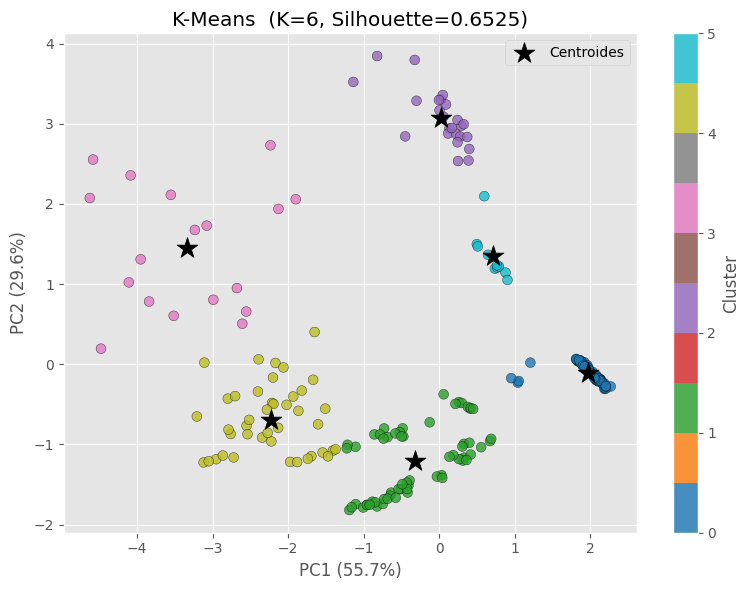

In [12]:
# Modelo K-Means final 
# Ajustamos K según el análisis anterior
K_OPTIMO = best_k_sil   # o el valor que el codo y silhouette indiquen

km_final = KMeans(n_clusters=K_OPTIMO, n_init=25, random_state=SEED)
labels_km = km_final.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, labels_km)
print(f'K-Means  |  K={K_OPTIMO}  |  Silhouette={sil_km:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='tab10',
                     alpha=0.8, edgecolors='k', linewidths=0.3, s=50)
# Centroides
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], c='black', s=250,
           marker='*', label='Centroides', zorder=5)
ax.set_title(f'K-Means  (K={K_OPTIMO}, Silhouette={sil_km:.4f})')
ax.set_xlabel(f'PC1 ({var1:.1%})')
ax.set_ylabel(f'PC2 ({var2:.1%})')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

En este gráfico final observamos una separación clara de los seis grupos. Las estrellas negras son los centroides y actúan como el centro o puntos medios de cada categoría. La cohesión de los grupos nos da a entender que el PCA ha logrado capturar las características físicas necesarias para distinguir los tipos de estrellas con éxito. 

### 3.2. Hierarchical Clustering/Dendrogramas

A continuación utilizaremos Clustering Jerárquico para evaluar diferentes funciones de enlace (linkage) para detemrinar cúal representa mejor la morfología de nuestras estrellas. 

Tambien utilizaremos el método de Ward ya que es el más robusto para minimizar la inercia dentro de los grupos, lo que facilita la identificación de categorías compactas.

A diferencia de K-Means, este algoritmo no requiere definir antes el número de clusters, lo que nos permite visualizar la estructura del dataset en forma de árbol (dendrograma).

In [20]:
def plot_dendrogram(model, **kwargs):
    """Extrae info de AgglomerativeClustering y representa el dendrograma."""
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

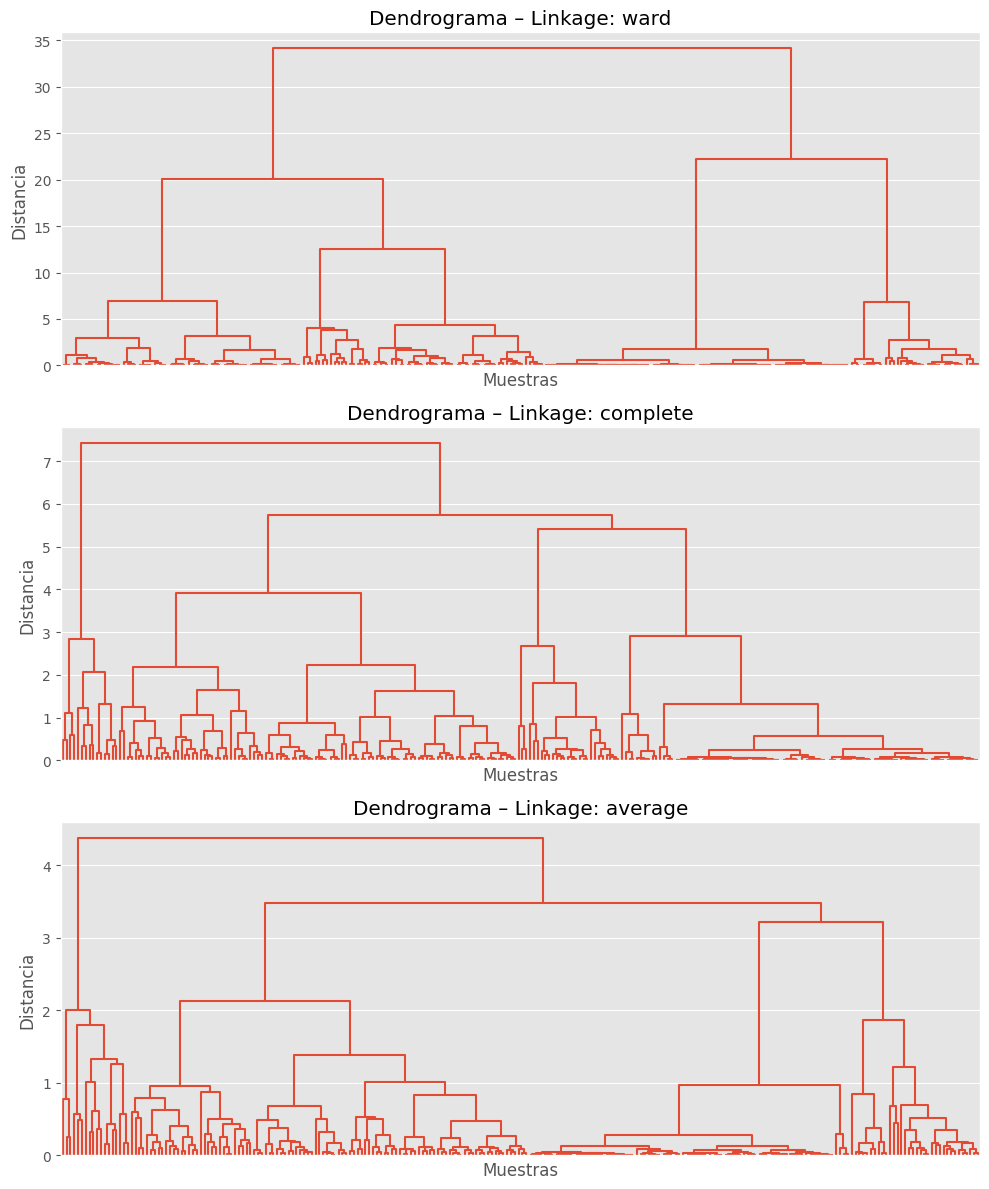

In [ ]:
# Comparación de linkages 
# Comparamos diferentes criterios de enlace (linkage) para ver cuál preserva mejor 
# la estructura espacial de las componentes principales.

linkages = ['ward', 'complete', 'average']
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

for ax, link in zip(axs, linkages):
    metric = 'euclidean'
    m = AgglomerativeClustering(
        linkage=link,
        metric=metric if link != 'ward' else 'euclidean',
        distance_threshold=0,
        n_clusters=None
    )
    m.fit(X_pca)
    plot_dendrogram(m, color_threshold=0, ax=ax, no_labels=True)
    ax.set_title(f'Dendrograma – Linkage: {link}')
    ax.set_xlabel('Muestras')
    ax.set_ylabel('Distancia')

plt.tight_layout()
plt.show()

Tras analizar estas tres gráficas vemos que Ward es el que presenta una estructura más equilibrada y limpia, con distancias verticales claras que facilitan la identificación de grupos compactos. 

Por otro lado, tanto complete como average tienen a generar agrupaciones menos compensadas (clusters muy grandes frente a otros muy pequeños) lo que dificula la clasificación de las estrellas.

Es por esto que nos quedamos con el método Ward, ya que minimiza la varianza dentro de cada cluster.

Nº óptimo de clusters (Silhouette, linkage=ward): 7  (score=0.6321)


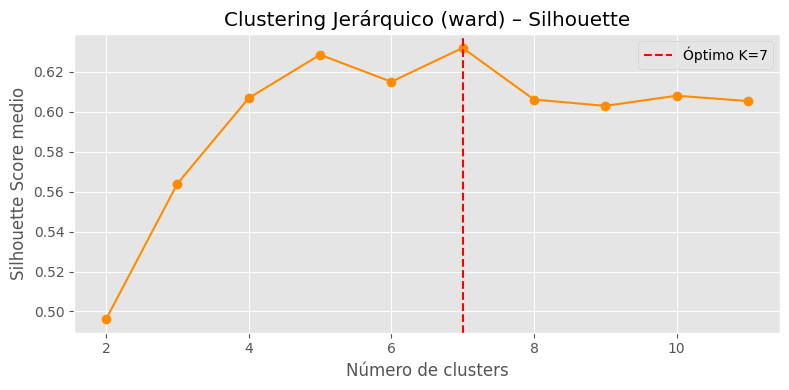

In [26]:
# Selección de linkage y número óptimo de clusters vía Silhouette 
# Usamos 'ward' por ser el mejor según lo que hemos visto anteriormente
LINKAGE_ELEGIDO = 'ward'

range_n = range(2, 12)
sil_hc  = []

for n in range_n:
    m = AgglomerativeClustering(linkage=LINKAGE_ELEGIDO, n_clusters=n)
    lab = m.fit_predict(X_pca)
    sil_hc.append(silhouette_score(X_pca, lab))

best_n_hc = list(range_n)[np.argmax(sil_hc)]
print(f'Nº óptimo de clusters (Silhouette, linkage={LINKAGE_ELEGIDO}): {best_n_hc}  (score={max(sil_hc):.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(range_n), sil_hc, marker='o', color='darkorange')
ax.axvline(x=best_n_hc, linestyle='--', color='red', label=f'Óptimo K={best_n_hc}')
ax.set_title(f'Clustering Jerárquico ({LINKAGE_ELEGIDO}) – Silhouette')
ax.set_xlabel('Número de clusters')
ax.set_ylabel('Silhouette Score medio')
ax.legend()
plt.tight_layout()
plt.show()

Como vemos en la gráfica, el score máximo se encuentra en K=7, con un valor de 0,6321.

Nº clusters por mayor salto: 2
Altura de corte sugerida: 22.2498


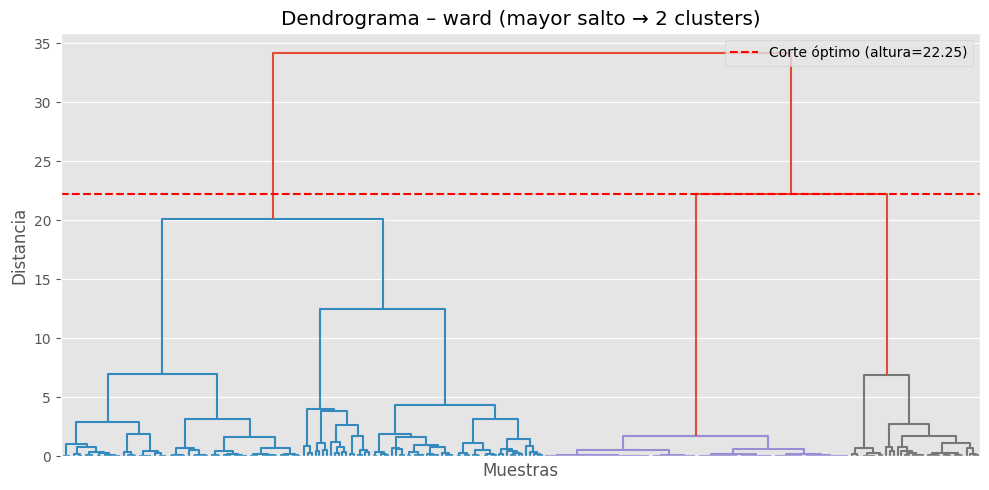

In [ ]:
# Dendrograma con corte óptimo (método del mayor salto) 
Z = sch.linkage(X_pca, method=LINKAGE_ELEGIDO)
heights = Z[:, 2]
diffs   = np.diff(heights)
idx_max = np.argmax(diffs)
altura_corte = heights[idx_max]
n_clusters_salto = len(heights) - idx_max

print(f'Nº clusters por mayor salto: {n_clusters_salto}')
print(f'Altura de corte sugerida: {altura_corte:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
sch.dendrogram(Z, color_threshold=altura_corte, ax=ax, no_labels=True)
ax.axhline(y=altura_corte, color='red', linestyle='--',
           label=f'Corte óptimo (altura={altura_corte:.2f})')
ax.set_title(f'Dendrograma – {LINKAGE_ELEGIDO} (mayor salto → {n_clusters_salto} clusters)')
ax.set_xlabel('Muestras')
ax.set_ylabel('Distancia')
ax.legend()
plt.tight_layout()
plt.show()

El corte sugerido es a una altura de 22,25, lo que indica que la división natural más fuerte del dataset es de solo 2 clusters. Esto probablemente separe estrellas que son frias/pequeñas de estrellas que son calientes/gigantes.

Pero como el índice de Silhouette hace una clasificación más fina, nos quedamos con ese.

Hierarchical  |  K=7  |  Linkage=ward  |  Silhouette=0.6321


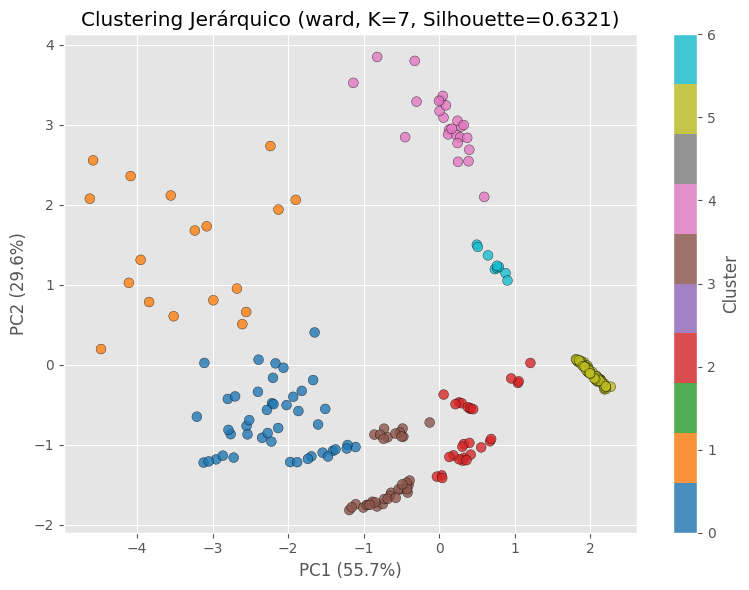

In [ ]:
# Modelo Jerárquico final 
N_HC = best_n_hc   # usar el indicado por Silhouette

hc_final   = AgglomerativeClustering(linkage=LINKAGE_ELEGIDO, n_clusters=N_HC)
labels_hc  = hc_final.fit_predict(X_pca)
sil_hc_fin = silhouette_score(X_pca, labels_hc)

print(f'Hierarchical  |  K={N_HC}  |  Linkage={LINKAGE_ELEGIDO}  |  Silhouette={sil_hc_fin:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, cmap='tab10',
                     alpha=0.8, edgecolors='k', linewidths=0.3, s=50)
ax.set_title(f'Clustering Jerárquico ({LINKAGE_ELEGIDO}, K={N_HC}, Silhouette={sil_hc_fin:.4f})')
ax.set_xlabel(f'PC1 ({var1:.1%})')
ax.set_ylabel(f'PC2 ({var2:.1%})')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

El modelo final lo hemos hecho con Ward y K=7 sobre los componentes de PCA y podemos ver en el dibujo que el modelo identifica con mucha precisión las nubes de puntos densas visibles en el plano PCA.

Mientras que K-Means concluia que lo mejor eran 6 grupos, este modelo jerárquico detecta una sub-división adicional (7 grupos). Esto se puede deber a que el método jerárquico es más sensible a la estructura de árbol de los datos, encontrando una sutil diferencia dentro de una de las clases principales.

Este modelo nos da un Silhouette de 0,6321, lo que indica que aunque hemos forzado un grupo más, los clusters siguen estando muy bien definidos y separados entre si.

A pesar de que este modelo es bueno, el modelo de K-Means con K=6 es un poco mejor, ya que tiene un Silhouette de 0,6525 y se ajusta de forma más exacta a la realidad astronómica presentada en el enunciado.

### 3.3. DBSCAN

En este apartado utilizamos el algoritmo de DBSCAN, que está basado en la densidad. Este método encuentra grupos de forma orgánica y es capaz de identificar puntos de ruido (outliers). Para configurarlo necesitamos el hiperparámetro "eps" que es el radio de vecindad, y "min_samples" que es la densidad mínima.

In [ ]:
# Instalamos DBCV si no estaba ya instalado
import subprocess
subprocess.run(['pip', 'install', 'git+https://github.com/FelSiq/DBCV', '--quiet'], capture_output=True)
print('DBCV instalado.')

DBCV instalado.


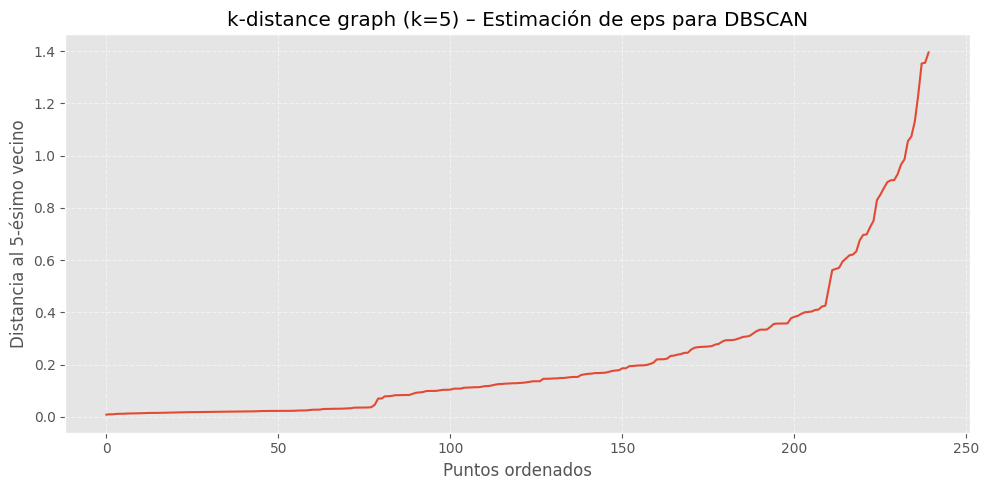

eps sugerida por heurística k-distance: 0.4254


In [29]:
import dbcv as dbcv_module

# Heurística k-distance para estimar eps 
MIN_SAMPLES_HEUR = 5

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES_HEUR)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
sorted_dists  = np.sort(distances[:, MIN_SAMPLES_HEUR - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_dists)
ax.set_title(f'k-distance graph (k={MIN_SAMPLES_HEUR}) – Estimación de eps para DBSCAN')
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al {MIN_SAMPLES_HEUR}-ésimo vecino')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Estimación del codo: buscar el punto de máxima curvatura (segunda derivada)
segunda_deriv = np.diff(sorted_dists, n=2)
codo_idx      = np.argmax(segunda_deriv) + 1
eps_heuristica = sorted_dists[codo_idx]
print(f'eps sugerida por heurística k-distance: {eps_heuristica:.4f}')

In [30]:
# Grid search de hiperparámetros con DBCV
# Probamos un rango alrededor de la eps heurística
eps_base = round(eps_heuristica, 2)
eps_values     = np.round(np.arange(max(0.05, eps_base - 0.3),
                                     eps_base + 0.5, 0.05), 2)
min_samples_vals = [3, 4, 5, 6, 7]

resultados = []
print(f"{'MS':<4} | {'EPS':<6} | {'Clusters':<10} | {'% Ruido':<9} | {'DBCV Score'}")
print("-" * 55)

for ms in min_samples_vals:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=ms, metric='euclidean').fit(X_pca)
        labels = db.labels_
        n_cl   = len(set(labels) - {-1})
        pct_n  = (list(labels).count(-1) / len(labels)) * 100

        if n_cl >= 2:
            score = dbcv_module.dbcv(X_pca, labels)
            resultados.append({'eps': eps, 'min_samples': ms,
                                'n_clusters': n_cl, 'pct_noise': pct_n,
                                'dbcv': score})
            print(f"{ms:<4} | {eps:<6} | {n_cl:<10} | {pct_n:>7.1f}% | {score:.4f}")
        else:
            print(f"{ms:<4} | {eps:<6} | {n_cl:<10} | {pct_n:>7.1f}% | —")

df_res = pd.DataFrame(resultados)
best   = df_res.loc[df_res['dbcv'].idxmax()]
print(f"\n✓ Mejor combinación → eps={best['eps']}, min_samples={int(best['min_samples'])}, "
      f"clusters={int(best['n_clusters'])}, DBCV={best['dbcv']:.4f}")

MS   | EPS    | Clusters   | % Ruido   | DBCV Score
-------------------------------------------------------
3    | 0.13   | 17         |    25.4% | 0.6893
3    | 0.18   | 14         |    17.5% | 0.7608
3    | 0.23   | 14         |    14.2% | 0.7687
3    | 0.28   | 11         |    13.3% | 0.6908
3    | 0.33   | 10         |    10.0% | 0.6713
3    | 0.38   | 9          |     7.5% | 0.6393
3    | 0.43   | 7          |     7.5% | 0.6255
3    | 0.48   | 7          |     6.7% | 0.6293
3    | 0.53   | 6          |     5.0% | 0.5108
3    | 0.58   | 7          |     2.1% | 0.2126
3    | 0.63   | 4          |     1.7% | -0.0836
3    | 0.68   | 3          |     1.7% | 0.0760
3    | 0.73   | 3          |     1.7% | 0.0760
3    | 0.78   | 4          |     0.4% | 0.0846
3    | 0.83   | 3          |     0.4% | -0.2206
3    | 0.88   | 3          |     0.0% | -0.2230
4    | 0.13   | 8          |    37.9% | 0.5961
4    | 0.18   | 11         |    24.6% | 0.7200
4    | 0.23   | 12         |    17.5% | 0.7

DBSCAN  |  eps=0.58  |  min_samples=5  |  Clusters=4  |  Ruido=20  |  DBCV=0.8320


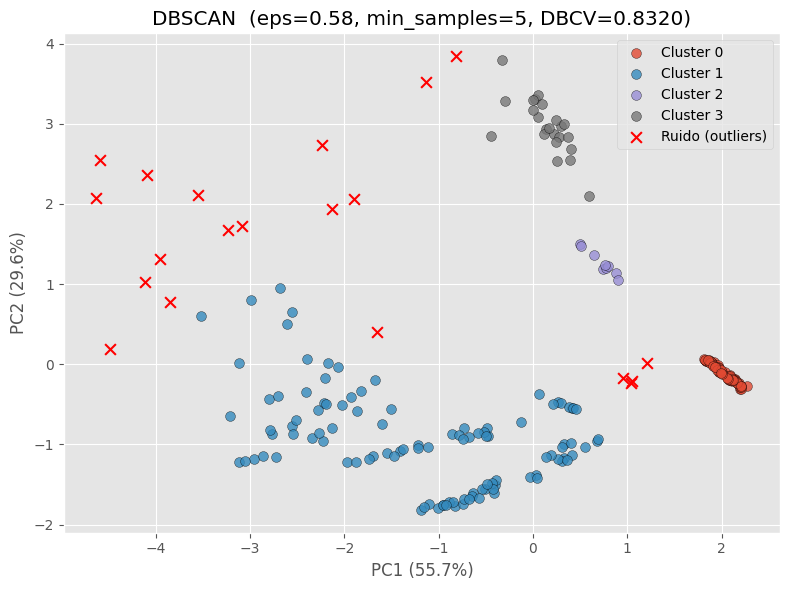

In [31]:
# Modelo DBSCAN final
EPS_FINAL = best['eps']
MS_FINAL  = int(best['min_samples'])

db_final  = DBSCAN(eps=EPS_FINAL, min_samples=MS_FINAL, metric='euclidean')
labels_db = db_final.fit_predict(X_pca)

n_clusters_db = len(set(labels_db) - {-1})
n_noise_db    = list(labels_db).count(-1)
dbcv_score    = dbcv_module.dbcv(X_pca, labels_db)

print(f'DBSCAN  |  eps={EPS_FINAL}  |  min_samples={MS_FINAL}  '
      f'|  Clusters={n_clusters_db}  |  Ruido={n_noise_db}  |  DBCV={dbcv_score:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
# Clusters normales
for cl in sorted(set(labels_db) - {-1}):
    mask = labels_db == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cl}',
               alpha=0.8, edgecolors='k', linewidths=0.3, s=50)
# Ruido
mask_noise = labels_db == -1
ax.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
           c='red', marker='x', s=60, label='Ruido (outliers)', zorder=5)
ax.set_title(f'DBSCAN  (eps={EPS_FINAL}, min_samples={MS_FINAL}, DBCV={dbcv_score:.4f})')
ax.set_xlabel(f'PC1 ({var1:.1%})')
ax.set_ylabel(f'PC2 ({var2:.1%})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. ¿Cuál es más recomendable usar?

A continuación analizaremos los resultados obtenidos en el anterior punto y elegiremos que pipeline de clustering, algoritmo, con sus hiperparámetros, recomendaríamos realizar.

## 5. Similitudes entre las clases de la tabla y los obtenidos en el punto 4

A partir de la tabla del enunciado de la práctica que contiene las clases y atributos asociados a las estrellas de la astonomía utiliza hambitualmente, comprobaremos y explicaremos si hay similitudes entre estas clases y los grupos obtenidos en el punto 4.